## Code: Import libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Code: Load dataset

In [39]:
df = pd.read_csv("insurance.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Code: Data information

In [40]:
print("Dataset Shape:", df.shape)

print("Dataset Information:")
df.info()

Dataset Shape: (1338, 7)
Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## Code: Numerical, categorical, target variable

In [41]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("Categorical Features:")
print(categorical_features)

print("Target Variable:")
print("charges")

Numerical Features:
['age', 'bmi', 'children', 'charges']
Categorical Features:
['sex', 'smoker', 'region']
Target Variable:
charges


C:\Users\ayush\AppData\Local\Temp\ipykernel_15704\2356412365.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns.tolist()


## Code: Missing values

In [42]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## Code: Preprocessing

In [43]:
X = df.drop("charges", axis=1)
y = df["charges"]

X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [44]:
categorical_columns = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(drop="first"), categorical_columns)],remainder="passthrough")

## Code: Train-test split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (1070, 6)
Testing Data  : (268, 6)


## Code: Model training

In [46]:
model = Pipeline([("preprocessor", preprocessor),("regressor", LinearRegression())])

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


## Code: Prediction

In [47]:
y_pred = model.predict(X_test)

print("First 10 Predictions:\n")

prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_df.head(10)

First 10 Predictions:



,Actual,Predicted
0,9095.06825,8969.550274
1,5272.17580,7068.747443
2,29330.98315,36858.410912
3,9301.89355,9454.678501
4,33750.29180,26973.173457
5,4536.25900,10864.113164
6,2117.33885,170.280841
7,14210.53595,16903.450287
8,3732.62510,1092.430936
9,10264.44210,11218.343184


## Code: Evaluation

In [48]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation
Mean Absolute Error (MAE): 4181.19
Mean Squared Error (MSE): 33596915.85
R² Score: 0.7836


## Code: Scatter plot

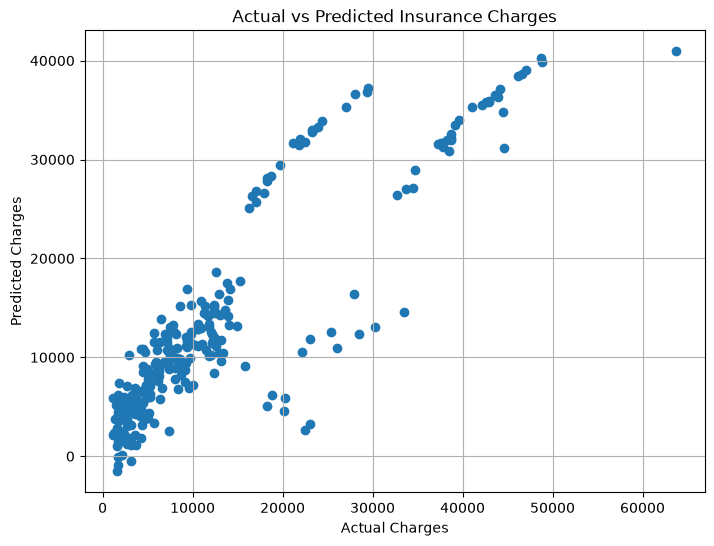

In [49]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.grid(True)

plt.show()

## Observations

1. The predicted insurance charges are reasonably close to the actual charges.

2. The model achieves a good R² score, indicating that Multiple Linear Regression explains a significant portion of the variation in insurance charges.

3. Some points are far from the diagonal trend, suggesting that Linear Regression cannot perfectly capture all complex relationships in the dataset.

## Conclusion

This assignment demonstrates the use of Multiple Linear Regression to predict medical insurance charges based on customer information such as age, BMI, sex, smoking status, number of children, and region. Among these features, smoking status has the strongest impact on insurance charges, followed by age and BMI. The model provides a good baseline for prediction, as indicated by the evaluation metrics. However, Linear Regression assumes a linear relationship between variables and may not accurately capture complex nonlinear patterns. More advanced machine learning algorithms such as Random Forest or XGBoost can provide better predictive performance.